In [1]:
import os
import warnings

# Нужен для загрузки данных и скриптов
os.chdir("/Data/EEG-Visual-Experiment")
warnings.filterwarnings('ignore')

### Load Dataset

Подключаем модуль для работы с данными. 

$\text{Dataset}[i] = \begin{bmatrix}
    & \text{mne.Raw EEG} & &\\ 
    & \text{mne.Raw EOG} & &\\ 
    \{ \text{index} & \text{subject\_id} & \text{trial\_id} & \text{task\_type} \}  \\ 
    & \text{pattern\_id} & &\\ 
    & \text{image} 6 \times 6 & & 
\end{bmatrix}$

In [2]:
from Scripts.Data_Loader import EIRDataset

In [3]:
path_perception = "./Generated/Data_Pattern/"
ds_perception = EIRDataset(path_perception, task_type="geometric", n_jobs=70)  # Do not set the `n_jobs` = 72 (Can crash the server)

Loading .fif files: 100%|██████████| 360/360 [00:25<00:00, 14.01it/s]


In [4]:
path_imagery = "./Generated/Data_Train/"
ds_imagery = EIRDataset(path_imagery, task_type="geometric", n_jobs=70)  # Do not set the `n_jobs` = 72 (Can crash the server)

Loading .fif files: 100%|██████████| 840/840 [00:37<00:00, 22.51it/s]


### Main

In [40]:
from typing import Optional, Literal

import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats

from Notebooks.Modeling.brainbert.utils.superlet import superlet, scale_from_period

In [41]:
def montage_electrode_schema(
    raw: mne.io.Raw,
    path: Optional[None] = None
) -> mne.io.Raw:
    s_raw = raw.copy().pick_types(eeg=True)
    if path is not None:
        montage = mne.channels.read_custom_montage(path)
        s_raw.set_montage(montage, on_missing="warn", match_case=False)
    return s_raw

In [42]:
t1, *_ = ds_perception[0]
eeg = montage_electrode_schema(t1)

data = eeg.get_data()
sfreq = eeg.info["sfreq"]

data.shape, sfreq

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


((63, 26001), 1000.0)

 #### Show Short Time Fourier Transform

In [27]:
def get_stft(
    x: np.ndarray,
    fs: int,
    clip_fs: int = -1,
    normalizing: Optional[Literal["zscore", "db"]] = None,
    **kwargs
):
    f, t, Zxx = signal.stft(x, fs, **kwargs)

    Zxx = Zxx[:clip_fs]
    f = f[:clip_fs]

    Zxx = np.abs(Zxx)
    clip = 5  # To handle boundary effects
    if normalizing == "zscore":
        Zxx = Zxx[:, clip:-clip]
        Zxx = stats.zscore(Zxx, axis=-1)
        t = t[clip:-clip]
    elif normalizing == "db":
        Zxx = np.log2(Zxx[:, clip:-clip])
        t = t[clip:-clip]

    if np.isnan(Zxx).any():
        import pdb
        pdb.set_trace()

    return f, t, Zxx


def plot_stft(wav, sfreq):
    f, t, linear = get_stft(wav, sfreq, clip_fs=40, nperseg=400, noverlap=350, normalizing="zscore")

    plt.figure(figsize=(15, 3))
    # f[-1] = 200
    g1 = plt.pcolormesh(t, f, linear, shading="gouraud", vmin=-3, vmax=5)

    cbar = plt.colorbar(g1)
    tick_font_size = 15
    cbar.ax.tick_params(labelsize=tick_font_size)
    cbar.ax.set_ylabel("Power (Arbitrary units)", fontsize=15)
    plt.xticks(fontsize=20)
    plt.ylabel("")
    plt.yticks(fontsize=20)
    plt.xlabel("Time (s)", fontsize=20)
    plt.ylabel("Frequency (Hz)", fontsize=20)


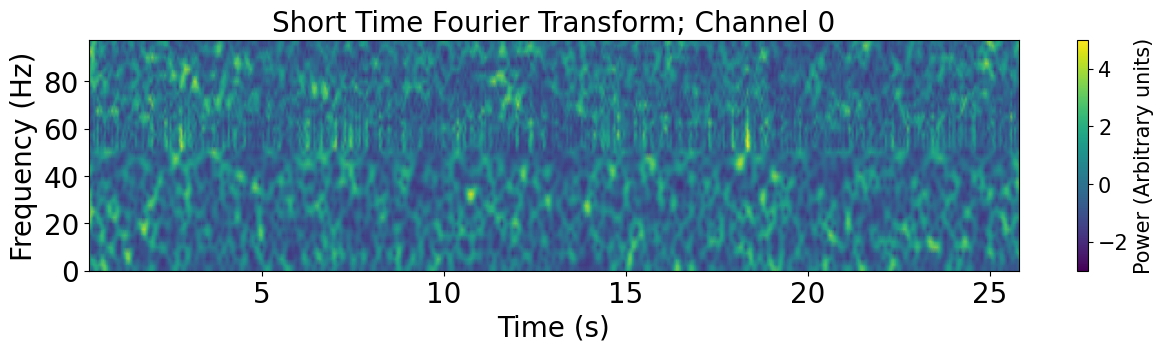

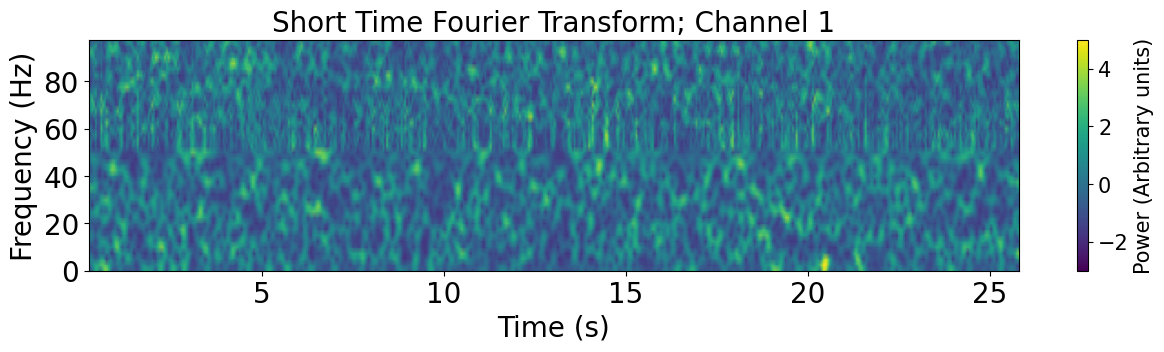

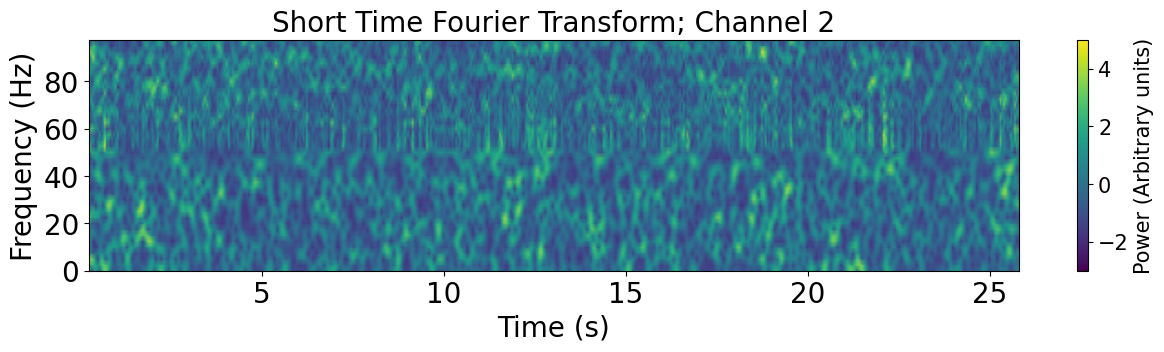

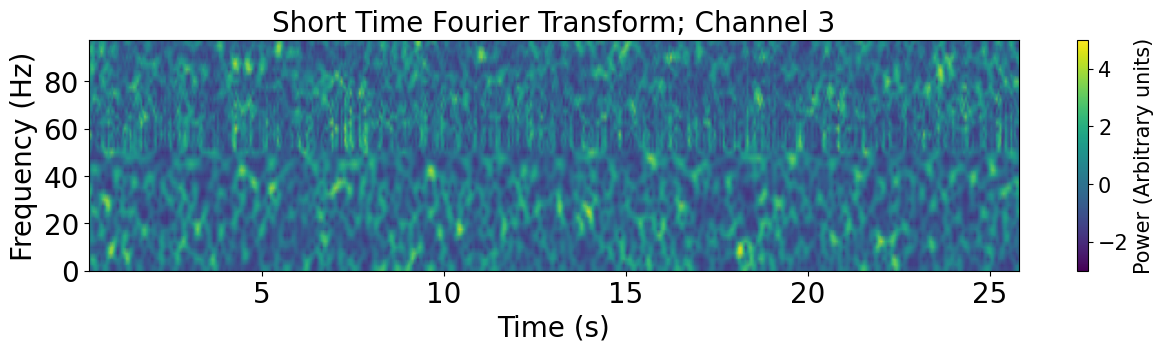

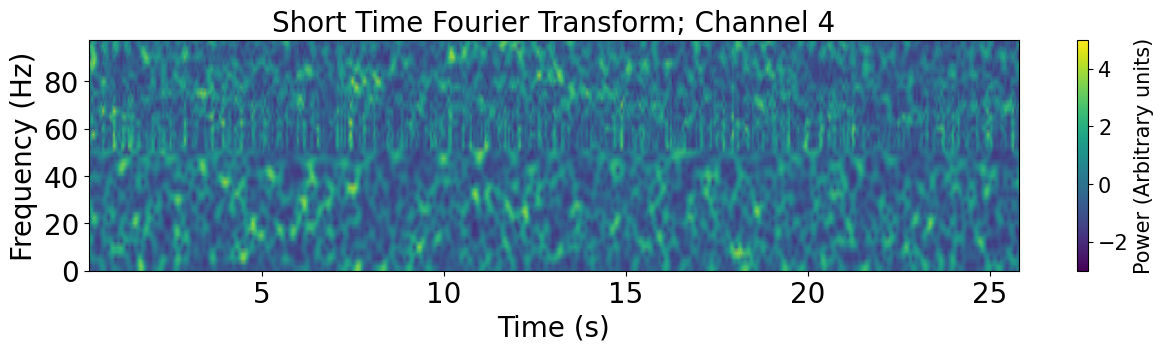

In [38]:
for channel in range(5):
    plot_stft(data[channel], sfreq)
    plt.title(f"Short Time Fourier Transform; Channel {channel}", fontsize=20)
    plt.show()

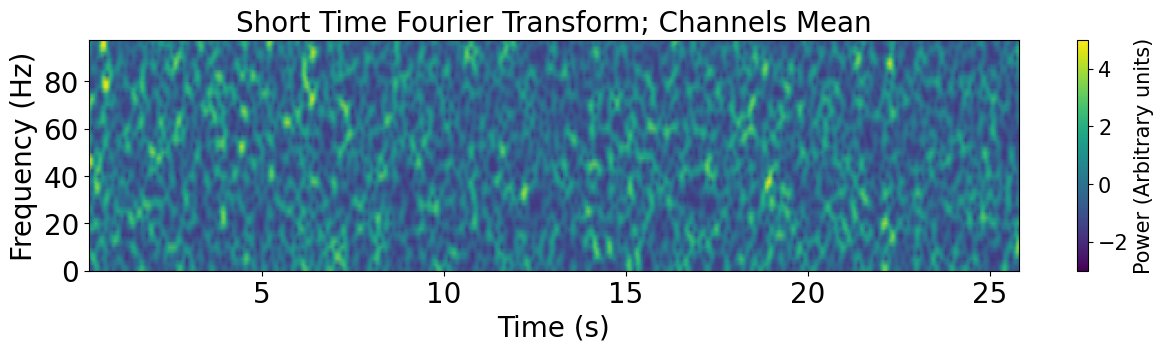

In [37]:
plot_stft(data.mean(axis=0), sfreq)
plt.title("Short Time Fourier Transform; Channels Mean", fontsize=20)
plt.show()

#### Show Superlet Transform

Time-frequency analysis with superlets based on `Time-frequency super-resolution with superlets` by Moca et al., 2021 Nature Communications

Implementation by Gregor Mönke: github.com/tensionhead

In [45]:
foi = np.linspace(1, 100, 50)
scales = scale_from_period(1 / foi)

spec = superlet(
    data[0, :],
    samplerate=sfreq,
    scales=scales,
    order_max=30,
    order_min=1,
    c_1=5,
    adaptive=True,
)

# amplitude scalogram
ampls = np.abs(spec)
ampls.shape

(50, 26001)

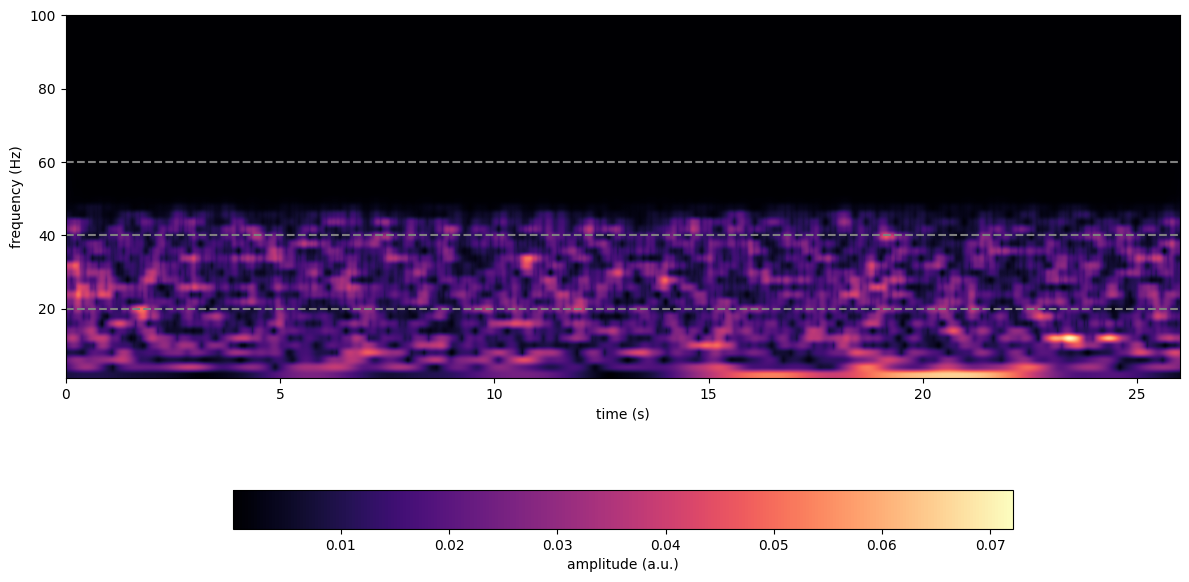

In [50]:
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(12, 6))

extent = [0, len(data[0, :]) / sfreq, foi[0], foi[-1]]
im = ax.imshow(ampls, cmap="magma", aspect="auto", extent=extent, origin='lower')

plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.7, pad=0.2, label='amplitude (a.u.)')

ax.plot([0, len(data[0, :]) / sfreq], [20, 20], "--", c='0.5')
ax.plot([0, len(data[0, :]) / sfreq], [40, 40], "--", c='0.5')
ax.plot([0, len(data[0, :]) / sfreq], [60, 60], "--", c='0.5')

ax.set_xlabel("time (s)")
ax.set_ylabel("frequency (Hz)")

fig.tight_layout()
plt.show()